In [16]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme(style="whitegrid")

In [17]:
df = pd.read_csv("../data/processed/clean_planet_data.csv")

In [18]:
df.head()

,planet_name,host_star,discovery_method,discovery_year,orbital_period_days,planet_radius_earth,planet_mass_earth,equilibrium_temperature,star_temperature,star_radius,star_mass,distance_pc,right_ascension,declination
0,11 Com b,11 Com,Radial Velocity,2007,323.21000,NaN,4914.898486,NaN,4874.0,13.76,2.09,93.1846,185.178779,17.793252
1,11 Com b,11 Com,Radial Velocity,2007,326.03000,NaN,6165.600000,NaN,4742.0,19.00,2.70,93.1846,185.178779,17.793252
2,11 Com b,11 Com,Radial Velocity,2007,NaN,NaN,5434.700000,NaN,NaN,NaN,2.60,93.1846,185.178779,17.793252
3,11 UMi b,11 UMi,Radial Velocity,2009,516.21997,NaN,4684.814200,NaN,4213.0,29.79,2.78,125.3210,229.274595,71.823943
4,11 UMi b,11 UMi,Radial Velocity,2009,NaN,NaN,3432.400000,NaN,NaN,NaN,1.70,125.3210,229.274595,71.823943


In [20]:
df.shape

(34424, 14)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 34424 entries, 0 to 34423
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   planet_name              34424 non-null  str    
 1   host_star                34424 non-null  str    
 2   discovery_method         34424 non-null  str    
 3   discovery_year           34424 non-null  int64  
 4   orbital_period_days      31171 non-null  float64
 5   planet_radius_earth      22152 non-null  float64
 6   planet_mass_earth        7356 non-null   float64
 7   equilibrium_temperature  12169 non-null  float64
 8   star_temperature         30926 non-null  float64
 9   star_radius              31127 non-null  float64
 10  star_mass                27950 non-null  float64
 11  distance_pc              33699 non-null  float64
 12  right_ascension          34388 non-null  float64
 13  declination              34388 non-null  float64
dtypes: float64(10), int64(1), str(3)


### Visualization 1 — Discoveries by Year (Line Chart)

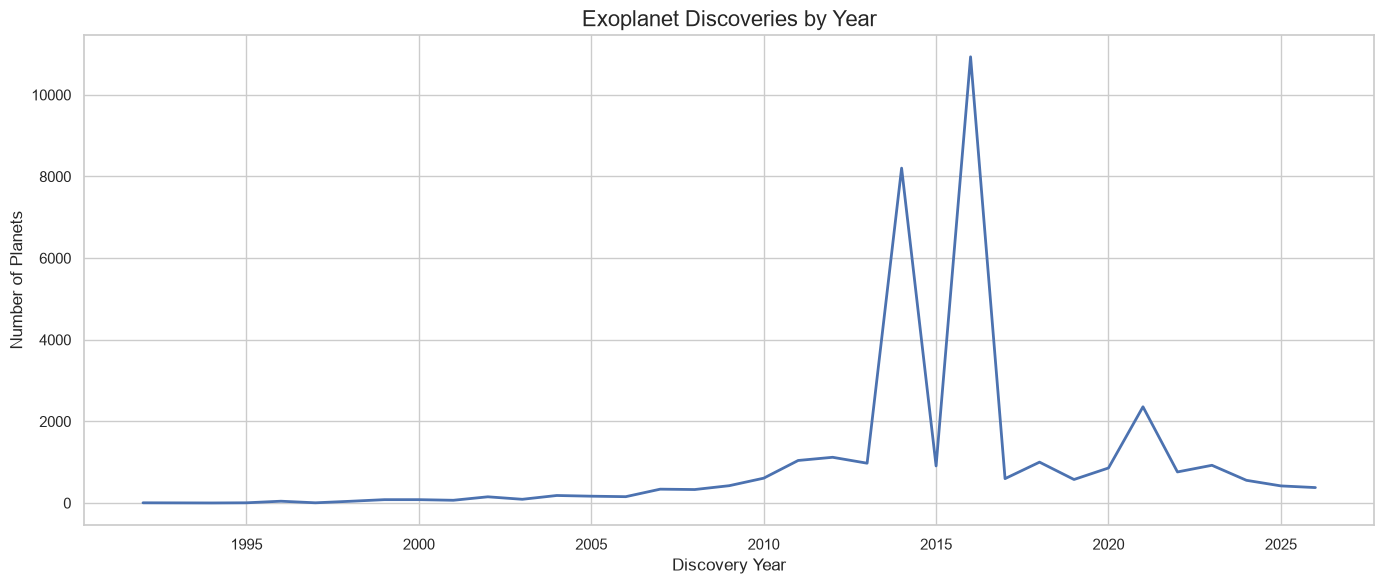

In [21]:
discoveries = (
    df["discovery_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(14,6))

plt.plot(
    discoveries.index,
    discoveries.values,
    linewidth=2
)

plt.title("Exoplanet Discoveries by Year", fontsize=16)
plt.xlabel("Discovery Year")
plt.ylabel("Number of Planets")

plt.tight_layout()
plt.show()

### Observation

- The number of discovered exoplanets increased significantly over the years.
- A noticeable surge occurs around the mid-2010s, indicating improvements in space missions and detection technologies.
- Recent years continue to contribute new discoveries, although annual counts may fluctuate depending on data release schedules.

### Visualization 2 — Top Discovery Methods (Horizontal Bar)

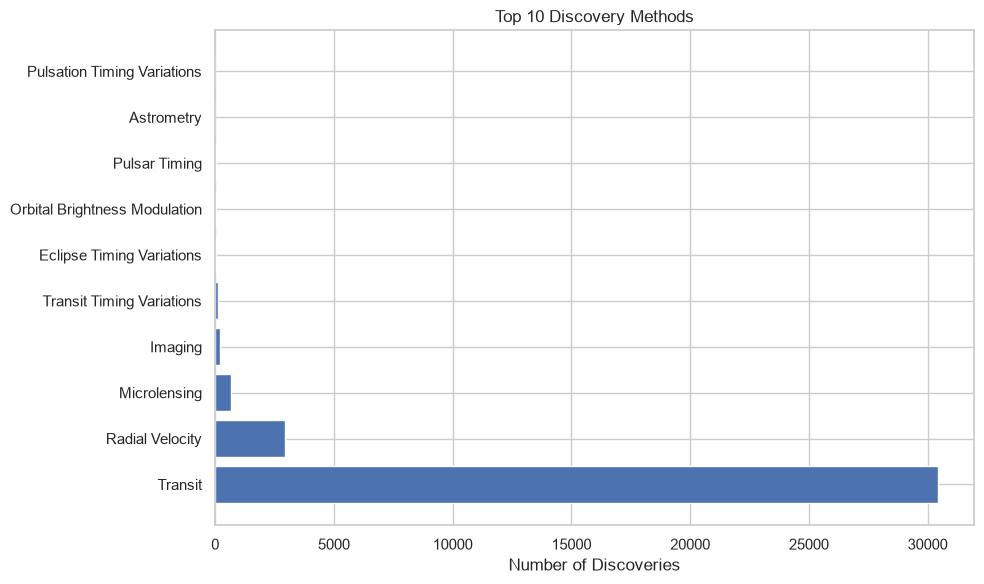

In [22]:
methods = (
    df["discovery_method"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    methods.index,
    methods.values
)

plt.title("Top 10 Discovery Methods")

plt.xlabel("Number of Discoveries")

plt.tight_layout()
plt.show()

### Observation

- Transit is expected to be the dominant discovery method.
- Other methods such as Radial Velocity and Imaging contribute fewer discoveries.
- The distribution highlights how different detection techniques vary in efficiency and applicability.

### Visualization 3 — Discovery Method Share (Pie Chart)

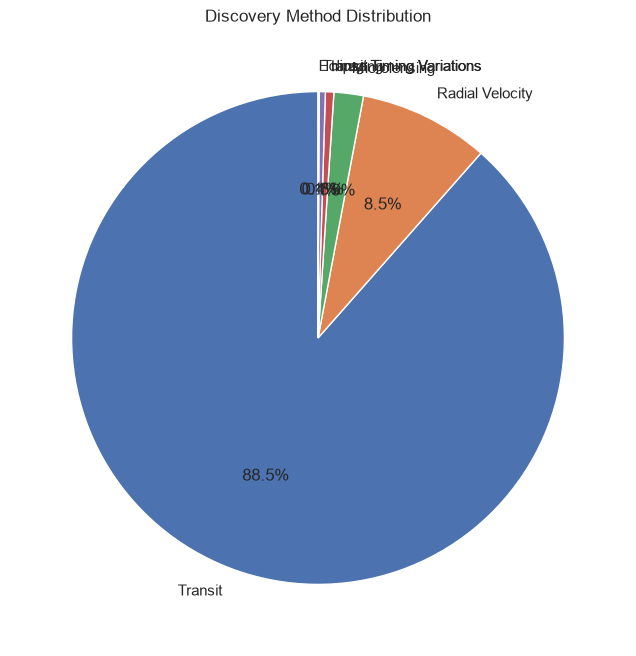

In [23]:
top_methods = (
    df["discovery_method"]
    .value_counts()
    .head(6)
)

plt.figure(figsize=(8,8))

plt.pie(
    top_methods.values,
    labels=top_methods.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Discovery Method Distribution")

plt.show()

### Observation

- A small number of discovery methods account for the majority of detected exoplanets.
- Transit occupies the largest share of discoveries.
- Several methods contribute only a small percentage of detections.

### Visualization 4 — Planet Radius Distribution

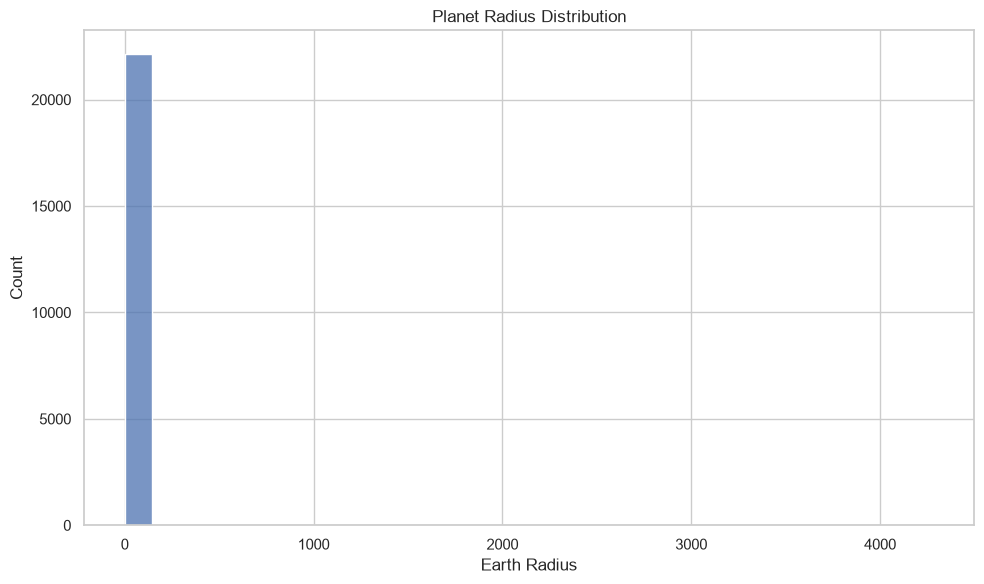

In [24]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="planet_radius_earth",
    bins=30
)

plt.title("Planet Radius Distribution")

plt.xlabel("Earth Radius")

plt.tight_layout()

plt.show()

### Observation

- Most detected exoplanets fall within a relatively small radius range.
- The distribution is positively skewed, with a few extremely large planets.
- Large gas giants are less common than smaller planets.

### Visualization 5 — Planet Radius Boxplot

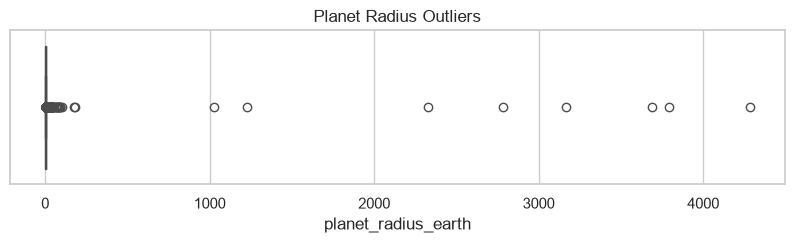

In [25]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["planet_radius_earth"]
)

plt.title("Planet Radius Outliers")

plt.show()

### Observation

- Several extreme outliers exist with exceptionally large radii.
- The majority of planets lie within a much smaller radius range.
- These outliers may influence statistical analyses and machine learning models.

### Visualization 6 — Planet Mass Distributio

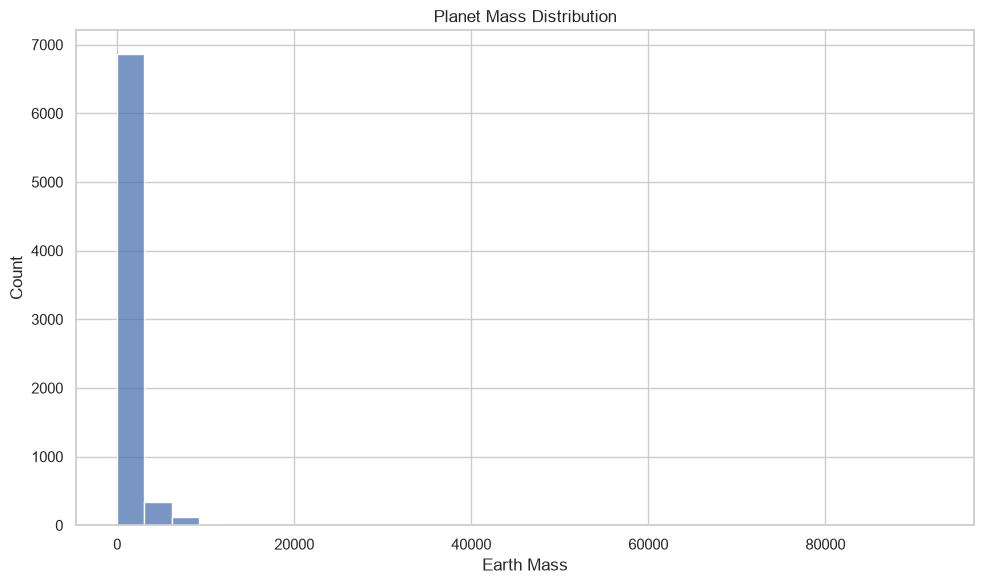

In [26]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="planet_mass_earth",
    bins=30
)

plt.title("Planet Mass Distribution")

plt.xlabel("Earth Mass")

plt.tight_layout()

plt.show()

### Observation

- Planet masses vary across a wide range.
- The distribution is highly right-skewed due to the presence of massive gas giants.
- Many planets have unknown mass measurements, resulting in missing values.

### Visualization 7 — Planet Mass Boxplot

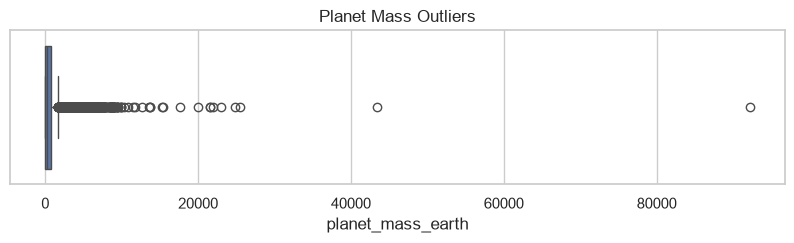

In [27]:
plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["planet_mass_earth"]
)

plt.title("Planet Mass Outliers")

plt.show()

### Observation

- Extreme mass values appear as outliers.
- Most planets occupy a relatively narrow mass range compared to the largest observed planets.
- The presence of these outliers suggests careful preprocessing before modeling.

### Visualization 8 — Star Temperature Distribution

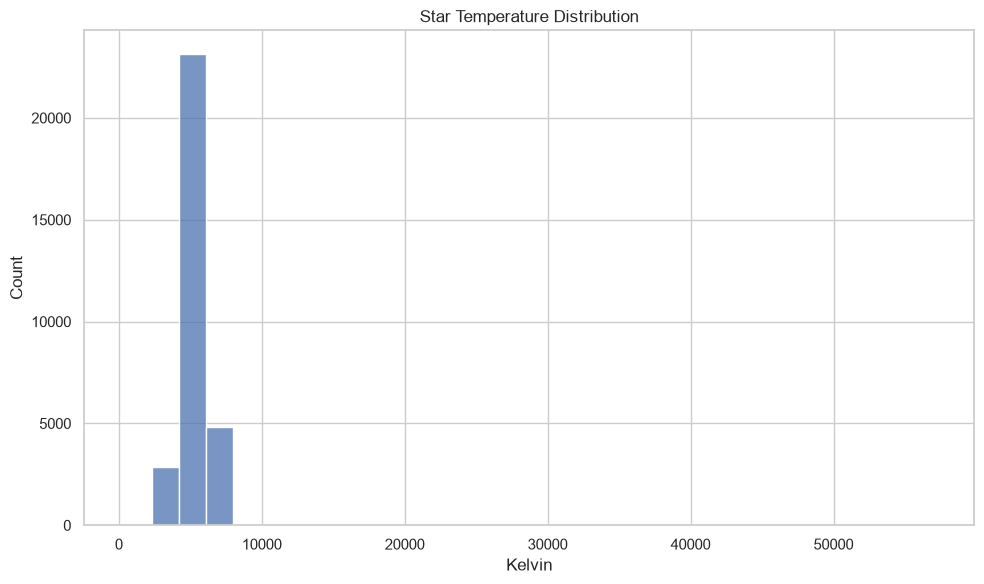

In [28]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="star_temperature",
    bins=30
)

plt.title("Star Temperature Distribution")

plt.xlabel("Kelvin")

plt.tight_layout()

plt.show()

### Observation

- Most host stars fall within a moderate temperature range.
- Extremely hot and extremely cool stars are comparatively rare.
- The distribution reflects the diversity of stellar systems hosting exoplanets.

### Visualization 9 — Star Mass Distribution

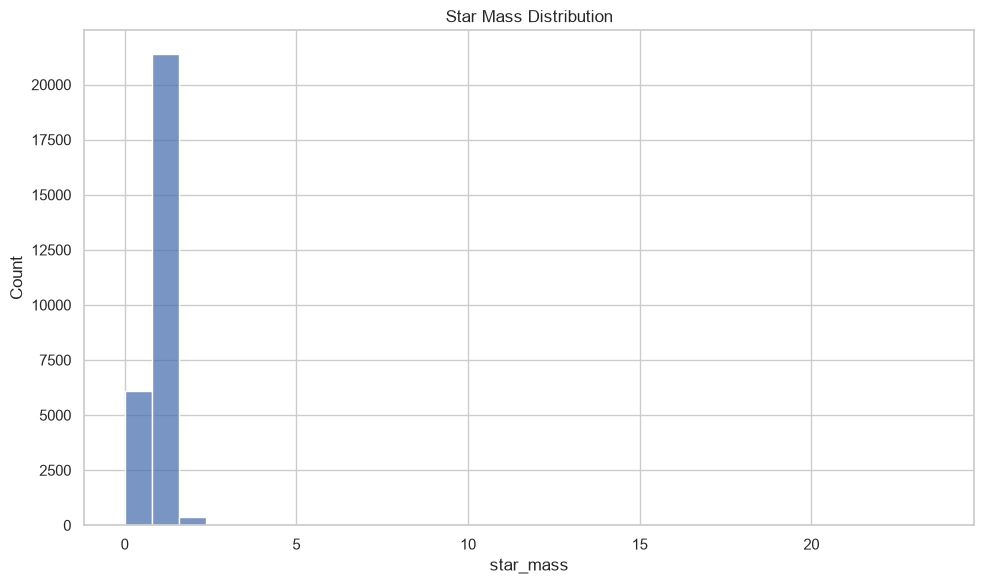

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="star_mass",
    bins=30
)

plt.title("Star Mass Distribution")

plt.tight_layout()

plt.show()

### Observation

- Most host stars have masses close to that of the Sun.
- Extremely massive stars are uncommon.
- The distribution is concentrated within a relatively narrow range.

### Visualization 10 — Star Radius Distribution

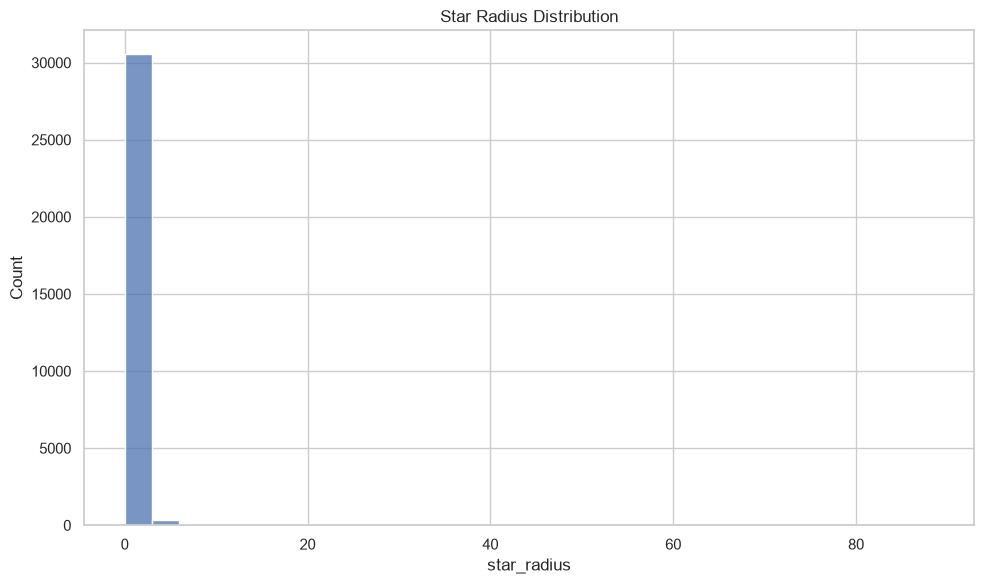

In [30]:
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x="star_radius",
    bins=30
)

plt.title("Star Radius Distribution")

plt.tight_layout()

plt.show()

### Observation

- Most stars have relatively small radii.
- A limited number of giant stars create a long-tailed distribution.
- Host star size varies considerably across planetary systems.

### Visualization 11 — Radius vs Mass (Scatter Plot)

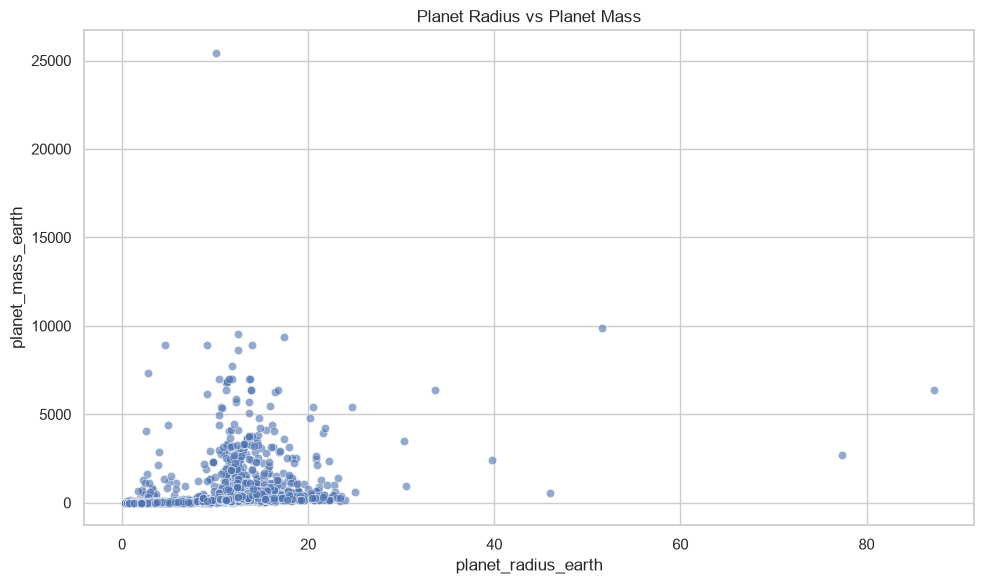

In [31]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="planet_radius_earth",
    y="planet_mass_earth",
    alpha=0.6
)

plt.title("Planet Radius vs Planet Mass")

plt.tight_layout()

plt.show()

### Observation

- A general positive relationship exists between planet radius and mass.
- Considerable variation is present, indicating that planets with similar radii can have different compositions and densities.
- Some extreme outliers are visible.

### Visualization 12 — Radius vs Temperature (Scatter Plot)

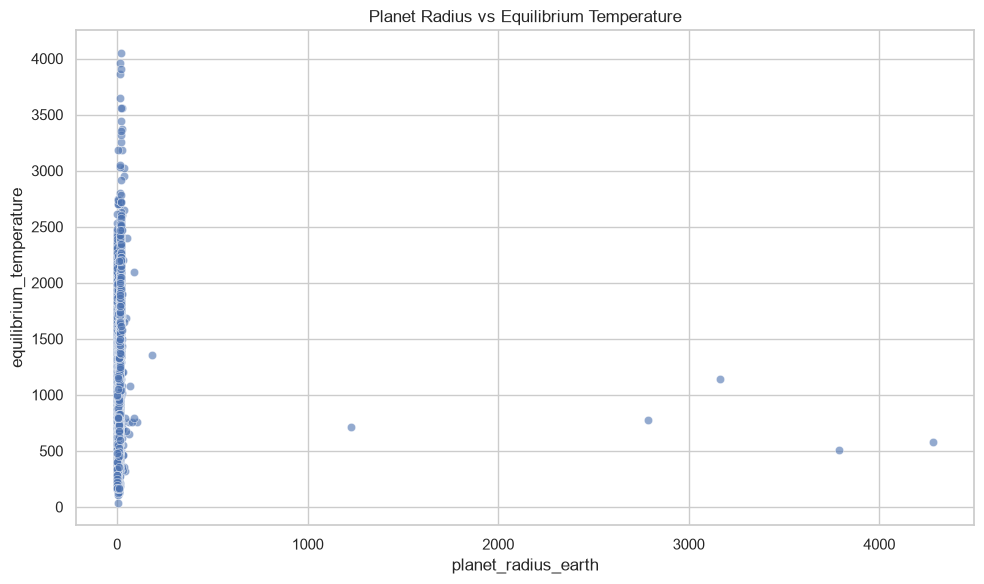

In [32]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="planet_radius_earth",
    y="equilibrium_temperature",
    alpha=0.6
)

plt.title("Planet Radius vs Equilibrium Temperature")

plt.tight_layout()

plt.show()

### Observation

- No strong linear relationship is immediately apparent.
- Planets of many different sizes exist across a broad temperature range.
- Additional features are required to accurately evaluate habitability.

### Visualization 13 — Distance Distribution (Log Scale)

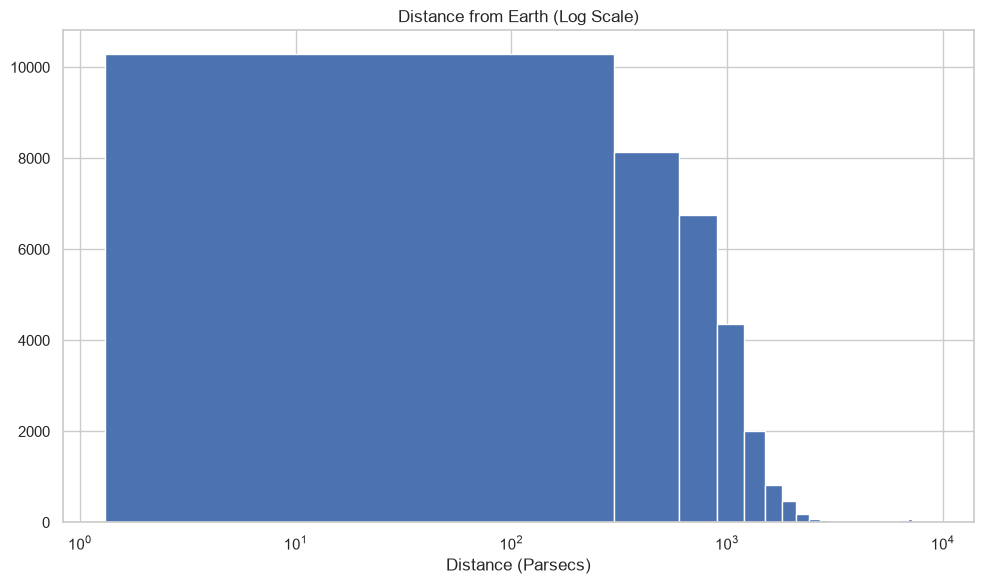

In [33]:
plt.figure(figsize=(10,6))

plt.hist(
    df["distance_pc"].dropna(),
    bins=30
)

plt.xscale("log")

plt.title("Distance from Earth (Log Scale)")

plt.xlabel("Distance (Parsecs)")

plt.tight_layout()

plt.show()

### Observation

- Most detected exoplanets are relatively close to Earth compared with the full observed range.
- The distribution spans several orders of magnitude, making a logarithmic scale more informative.
- A few planetary systems are located at very large distances.

### Visualization 14 — Stars with Most Planets

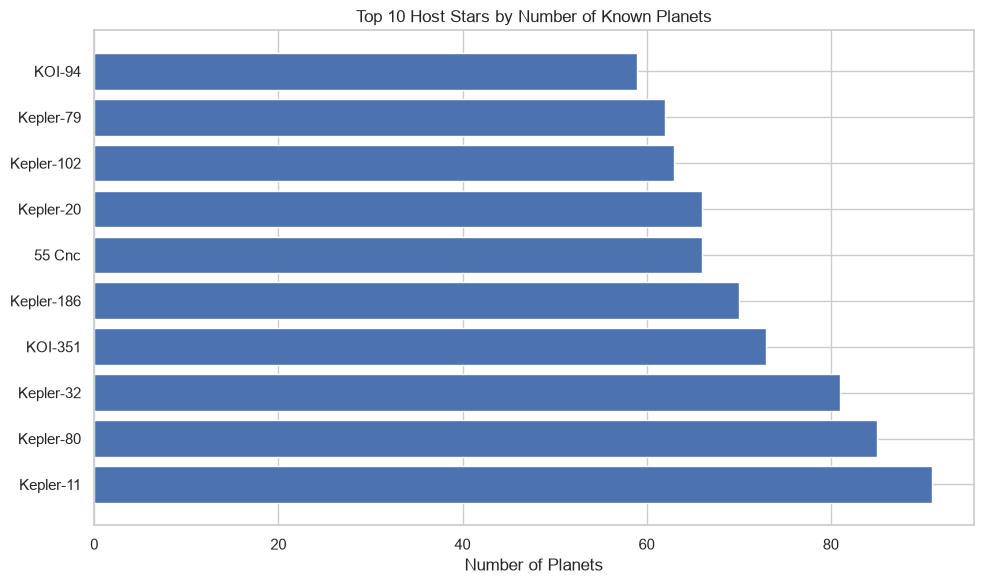

In [34]:
top_stars = (
    df["host_star"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10,6))

plt.barh(
    top_stars.index,
    top_stars.values
)

plt.title("Top 10 Host Stars by Number of Known Planets")

plt.xlabel("Number of Planets")

plt.tight_layout()

plt.show()

### Observation

- Certain host stars contain significantly more confirmed planets than others.
- Most stars host only a small number of known planets.
- Multi-planet systems provide valuable opportunities for comparative analysis.

### Visualization 15 — Correlation Heatmap

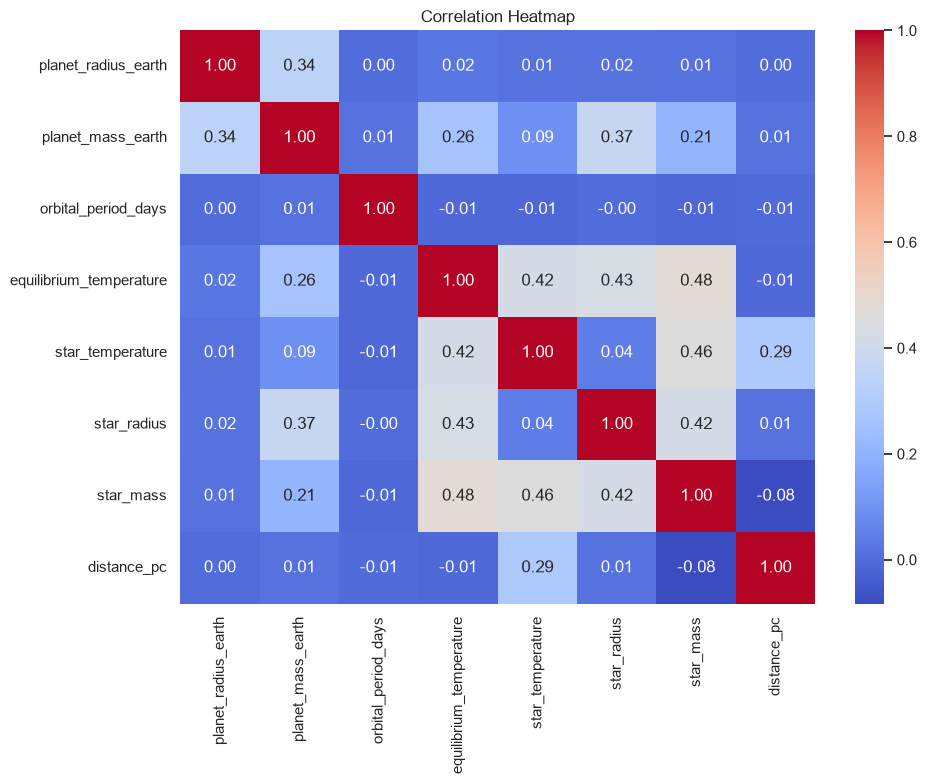

In [35]:
numerical_columns = [
    "planet_radius_earth",
    "planet_mass_earth",
    "orbital_period_days",
    "equilibrium_temperature",
    "star_temperature",
    "star_radius",
    "star_mass",
    "distance_pc"
]

plt.figure(figsize=(10,8))

sns.heatmap(
    df[numerical_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

### Observation

- Some numerical features exhibit moderate positive or negative correlations.
- Several variables show weak relationships, indicating that multiple factors influence planetary characteristics.
- No single feature completely explains another.

### Visualization 16 — Missing Values Percentage

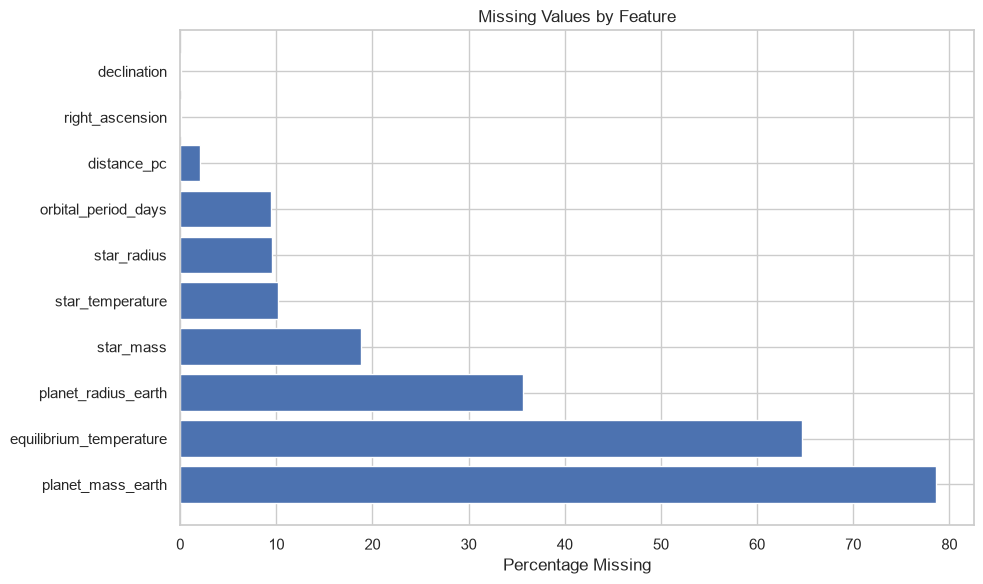

In [36]:
missing = (
    df.isnull().sum() / len(df) * 100
).sort_values(ascending=False)

missing = missing[missing > 0]

plt.figure(figsize=(10,6))

plt.barh(
    missing.index,
    missing.values
)

plt.title("Missing Values by Feature")

plt.xlabel("Percentage Missing")

plt.tight_layout()

plt.show()

### Observation

- Missing values are concentrated in specific scientific measurements such as planet mass and equilibrium temperature.
- Essential identification fields are complete.
- The missing values reflect unavailable scientific observations rather than data collection errors.